# Session 5: 5k-iter Smoke Variant Analysis

Loads the four (or fewer) variant runs in `outputs/runs/smoke5k/`,
compares their loss trajectories and latent-health diagnostics, and prints
the Session 5 decision string (HEALTHY / PARTIAL / TRIVIAL / WEAK / DEAD)
per the decision tree in `SESSION5_MEANINGFUL_SMOKE_5K.md` Section
"Analysis framework".

Input source: each run writes `metrics.jsonl` (one JSON object per
logged metric event, alongside W&B offline storage). Reading the JSONL
avoids needing a `wandb sync` first.

Pass/fail thresholds at iter 5000:
- PR(z) > 0.5 * d = 16 (healthy spread)
- 0.5 < probe_R^2_overall < 0.7 (decodable but not memorising c)
- SIGReg / anti-collapse loss below 5.0


In [1]:
from __future__ import annotations

import json
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name and not (REPO_ROOT / 'configs' / 'splits').exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
print('repo root:', REPO_ROOT)

SMOKE_DIR = REPO_ROOT / 'outputs' / 'runs' / 'smoke5k'
D = 32  # latent dim
PR_HEALTHY = 0.5 * D       # 16; Session 5 pass criterion
PR_FALLBACK = 0.3 * D      # 9.6; auto-fallback threshold (D5)
R2_PASS_LO = 0.5           # Session 5 pass criterion
R2_PASS_HI = 0.7           # auto-fallback ceiling (D5)
FINAL_ITER = 5000

repo root: /home/carlos/GUST-JEPA


## Section 1: Load variant runs


In [2]:
VARIANT_DIRS = {
    'A: SIGReg + BN': 'run_a_sigreg_bn',
    'B: SIGReg + LN': 'run_b_sigreg_ln',
    'C: VICReg + BN': 'run_c_vicreg_bn',
    'D: VICReg + LN': 'run_d_vicreg_ln',
}

def load_run_jsonl(run_dir: Path) -> tuple[dict, pd.DataFrame]:
    """Return (config_dict, metrics_df) for one run.

    Each line in metrics.jsonl is either {'event': 'config', ...} or
    {'event': 'log', 'step': int, **payload}. We coalesce all 'log'
    events into a single DataFrame indexed by step.
    """
    config = {}
    rows = defaultdict(dict)
    with open(run_dir / 'metrics.jsonl') as f:
        for line in f:
            evt = json.loads(line)
            if evt.get('event') == 'config':
                config = {k: v for k, v in evt.items() if k != 'event'}
            elif evt.get('event') == 'log':
                step = int(evt['step'])
                for k, v in evt.items():
                    if k in ('event', 'step'):
                        continue
                    rows[step][k] = v
    df = pd.DataFrame.from_dict(rows, orient='index').sort_index()
    df.index.name = 'step'
    return config, df

loaded: dict[str, tuple[dict, pd.DataFrame]] = {}
for label, subdir in VARIANT_DIRS.items():
    run_dir = SMOKE_DIR / subdir
    jsonl = run_dir / 'metrics.jsonl'
    if not jsonl.exists():
        print(f'  [{label}] not yet present: {jsonl}')
        continue
    cfg, df = load_run_jsonl(run_dir)
    n_iters = int(df.index.max()) if len(df) else 0
    print(f'  [{label}] {len(df)} log events, max step {n_iters}, anticollapse={cfg.get("anticollapse")}, proj={cfg.get("projection_norm")}')
    loaded[label] = (cfg, df)

if not loaded:
    print('NO RUNS LOADED. Start at least Run A before re-running this cell.')

  [A: SIGReg + BN] 200 log events, max step 4975, anticollapse=sigreg, proj=batchnorm
  [B: SIGReg + LN] 200 log events, max step 4975, anticollapse=sigreg, proj=layernorm
  [C: VICReg + BN] 200 log events, max step 4975, anticollapse=vicreg, proj=batchnorm
  [D: VICReg + LN] 200 log events, max step 4975, anticollapse=vicreg, proj=layernorm


## Section 2: Loss curves


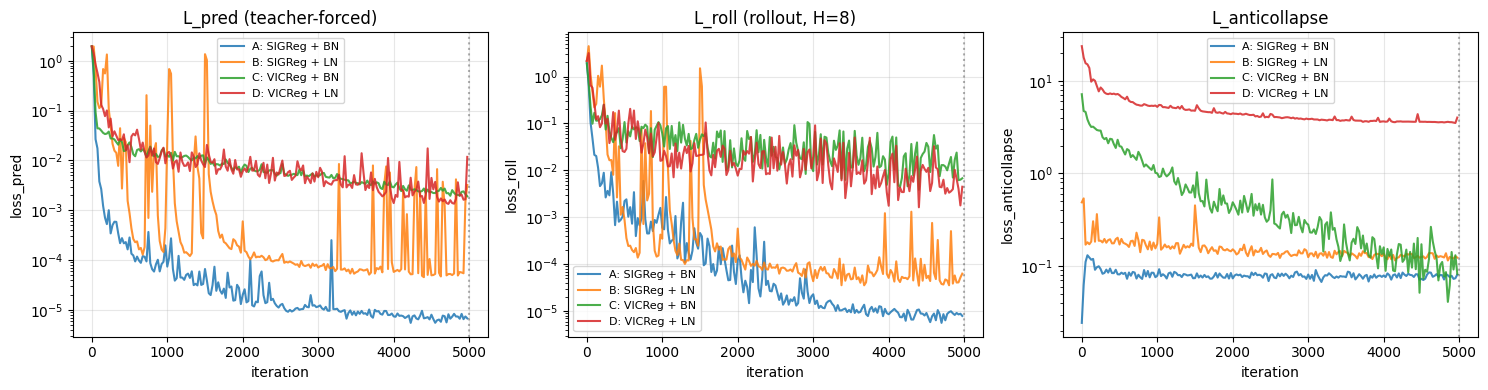

In [3]:
if loaded:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
    titles = ['L_pred (teacher-forced)', 'L_roll (rollout, H=8)', 'L_anticollapse']
    keys = ['loss_pred', 'loss_roll', 'loss_anticollapse']
    for ax, title, key in zip(axes, titles, keys):
        for label, (cfg, df) in loaded.items():
            sub = df[key].dropna()
            if len(sub):
                ax.plot(sub.index, sub.values, label=label, alpha=0.85)
        ax.set_xlabel('iteration')
        ax.set_ylabel(key)
        ax.set_yscale('log')
        ax.set_title(title)
        ax.axvline(FINAL_ITER, color='k', linestyle=':', alpha=0.3)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Section 3: Latent-health diagnostics (PR, probe R^2)


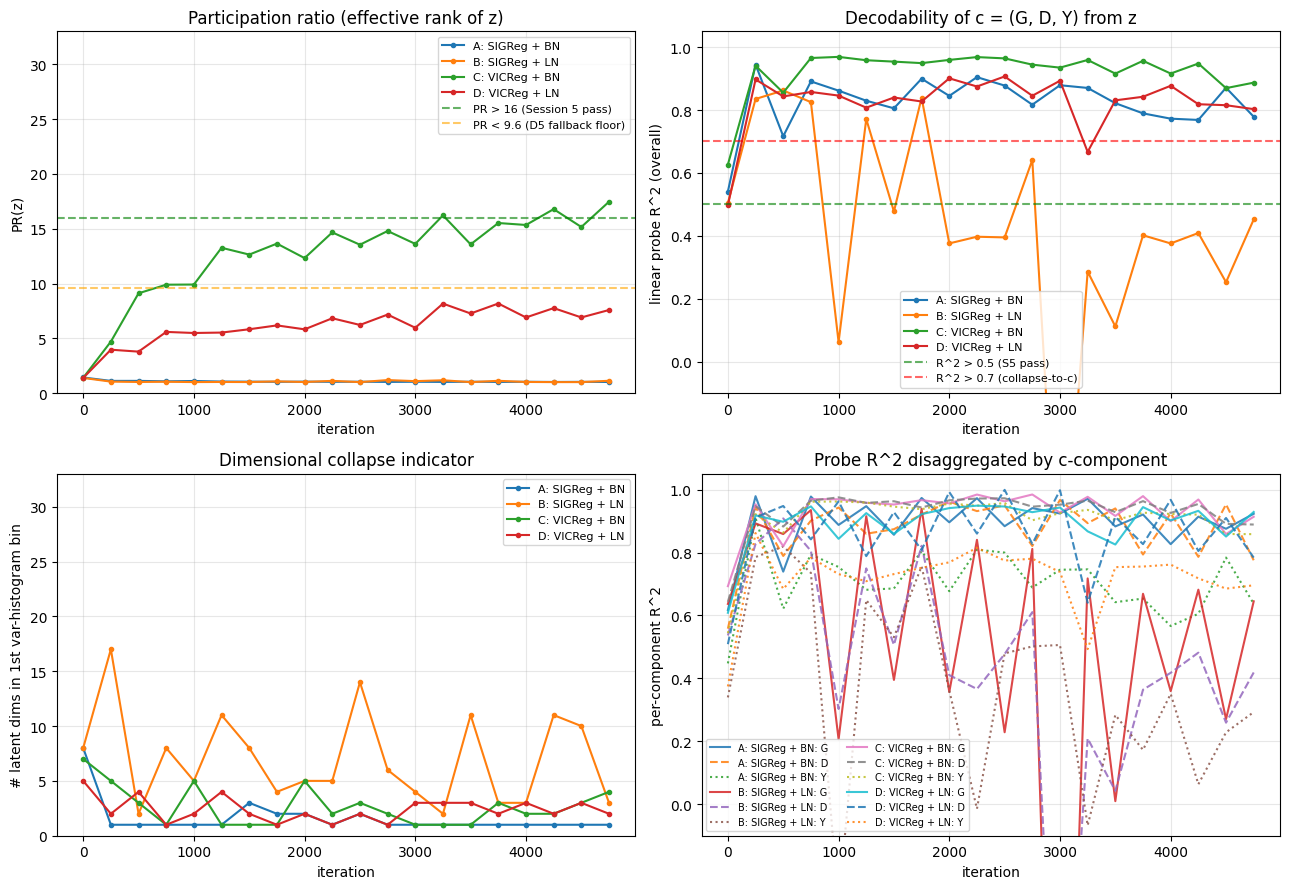

In [4]:
if loaded:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    ax_pr, ax_r2, ax_var, ax_r2c = axes.flatten()

    # PR(z) over iters
    for label, (cfg, df) in loaded.items():
        sub = df['diag/pr'].dropna()
        if len(sub):
            ax_pr.plot(sub.index, sub.values, label=label, marker='o', markersize=3)
    ax_pr.axhline(PR_HEALTHY, color='g', linestyle='--', alpha=0.6, label=f'PR > {PR_HEALTHY:.0f} (Session 5 pass)')
    ax_pr.axhline(PR_FALLBACK, color='orange', linestyle='--', alpha=0.6, label=f'PR < {PR_FALLBACK:.1f} (D5 fallback floor)')
    ax_pr.set_xlabel('iteration'); ax_pr.set_ylabel('PR(z)')
    ax_pr.set_title('Participation ratio (effective rank of z)')
    ax_pr.set_ylim(0, D + 1); ax_pr.grid(True, alpha=0.3); ax_pr.legend(fontsize=8)

    # probe r2_overall
    for label, (cfg, df) in loaded.items():
        sub = df['diag/r2_overall'].dropna()
        if len(sub):
            ax_r2.plot(sub.index, sub.values, label=label, marker='o', markersize=3)
    ax_r2.axhline(R2_PASS_LO, color='g', linestyle='--', alpha=0.6, label=f'R^2 > {R2_PASS_LO} (S5 pass)')
    ax_r2.axhline(R2_PASS_HI, color='r', linestyle='--', alpha=0.6, label=f'R^2 > {R2_PASS_HI} (collapse-to-c)')
    ax_r2.set_xlabel('iteration'); ax_r2.set_ylabel('linear probe R^2 (overall)')
    ax_r2.set_title('Decodability of c = (G, D, Y) from z')
    ax_r2.set_ylim(-0.1, 1.05); ax_r2.grid(True, alpha=0.3); ax_r2.legend(fontsize=8)

    # Per-component r2 traces (lower-left)
    for label, (cfg, df) in loaded.items():
        for comp, ls in [('G', '-'), ('D', '--'), ('Y', ':')]:
            key = f'diag/r2_{comp}'
            if key not in df.columns:
                continue
            sub = df[key].dropna()
            if len(sub):
                ax_r2c.plot(sub.index, sub.values, ls, label=f'{label}: {comp}', alpha=0.85, markersize=2)
    ax_r2c.set_xlabel('iteration'); ax_r2c.set_ylabel('per-component R^2')
    ax_r2c.set_title('Probe R^2 disaggregated by c-component')
    ax_r2c.set_ylim(-0.1, 1.05); ax_r2c.grid(True, alpha=0.3); ax_r2c.legend(fontsize=7, ncol=2)

    # Variance histogram counts at final iter (zero-bin proxy)
    for label, (cfg, df) in loaded.items():
        sub = df['diag/var_hist_counts_zero_bin'].dropna()
        if len(sub):
            ax_var.plot(sub.index, sub.values, label=label, marker='o', markersize=3)
    ax_var.set_xlabel('iteration'); ax_var.set_ylabel('# latent dims in 1st var-histogram bin')
    ax_var.set_title('Dimensional collapse indicator')
    ax_var.set_ylim(0, D + 1); ax_var.grid(True, alpha=0.3); ax_var.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


## Section 4: Combinatorial pass criterion

Place each variant at iter 5000 in the 2x2 outcome quadrant:

|              | probe_R^2 > 0.5         | probe_R^2 <= 0.5                          |
|--------------|-------------------------|-------------------------------------------|
| PR > 16      | **healthy**             | regulariser too strong / encoder broken   |
| PR <= 16     | trivial solution (collapse to c) | dead encoder                            |


In [5]:
def final_values(df: pd.DataFrame, key: str, near: int = FINAL_ITER) -> float | None:
    sub = df[key].dropna() if key in df.columns else pd.Series(dtype=float)
    if not len(sub):
        return None
    last_idx = sub.index[sub.index <= near]
    if not len(last_idx):
        return None
    return float(sub.loc[last_idx[-1]])

def quadrant(pr: float | None, r2: float | None) -> str:
    if pr is None or r2 is None:
        return 'n/a'
    if pr > PR_HEALTHY and r2 > R2_PASS_LO:
        return 'HEALTHY' if r2 < R2_PASS_HI else 'TRIVIAL_LITE'
    if pr > PR_HEALTHY and r2 <= R2_PASS_LO:
        return 'WEAK'
    if pr <= PR_HEALTHY and r2 > R2_PASS_LO:
        return 'TRIVIAL'
    return 'DEAD'

summary_rows = []
for label, (cfg, df) in loaded.items():
    pr = final_values(df, 'diag/pr')
    r2 = final_values(df, 'diag/r2_overall')
    L_anti = final_values(df, 'loss_anticollapse')
    L_pred = final_values(df, 'loss_pred')
    L_roll = final_values(df, 'loss_roll')
    summary_rows.append({
        'variant': label,
        'PR@5k': pr,
        'r2_overall@5k': r2,
        'L_pred@5k': L_pred,
        'L_roll@5k': L_roll,
        'L_anti@5k': L_anti,
        'quadrant': quadrant(pr, r2),
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.3f}' if x is not None else 'n/a'))


       variant  PR@5k  r2_overall@5k  L_pred@5k  L_roll@5k  L_anti@5k     quadrant
A: SIGReg + BN  1.025          0.779      0.000      0.000      0.081      TRIVIAL
B: SIGReg + LN  1.135          0.452      0.003      0.000      0.124         DEAD
C: VICReg + BN 17.463          0.887      0.002      0.007      0.083 TRIVIAL_LITE
D: VICReg + LN  7.588          0.803      0.012      0.004      4.007      TRIVIAL


## Section 5: PCA latent exploration (qualitative)

Load the best variant's final checkpoint, encode Test A held-out
encounters for the five smoke cases, run PCA on the (N, d=32) latent
set, plot PC1 vs PC2 coloured by (G, D, Y).

Healthy: G-coloured points form distinct clusters with smooth
within-case trajectories. Trivial: 5 tight clusters with no internal
structure. Broken: no PC structure related to either c or impact phase.


PCA on variant C: VICReg + BN (quadrant: TRIVIAL_LITE)


PCA over 192 latent points (d=32)


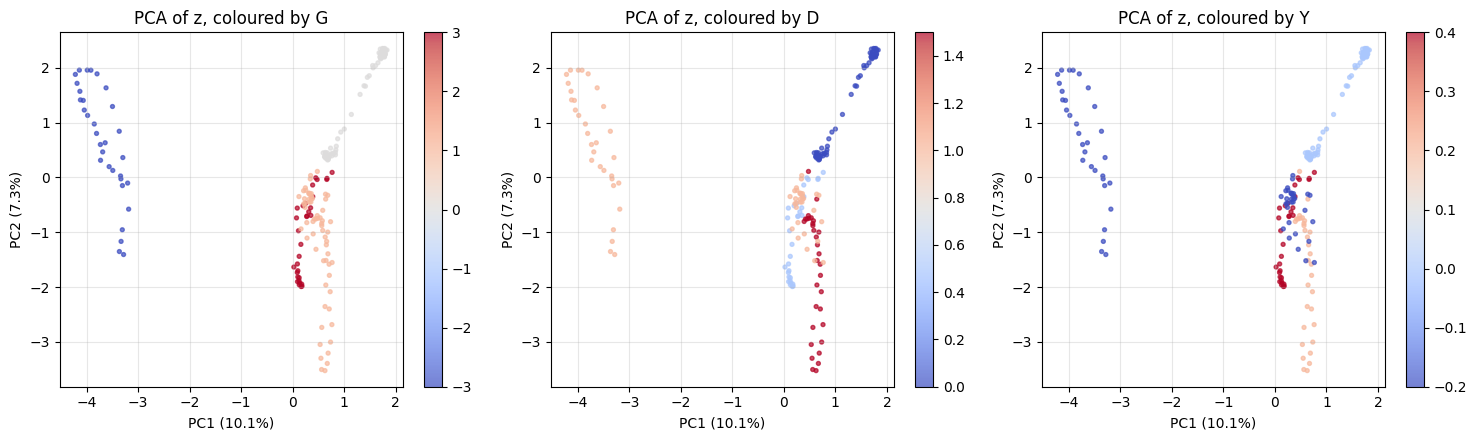

In [6]:
import torch
import yaml
from sklearn.decomposition import PCA

from src.data.episode_dataset import EpisodeDataset
from src.models.encoder import HybridCNNViTEncoder
from src.training.train_jepa import jepa_collate
from torch.utils.data import DataLoader

if summary_df.empty:
    print('skip: no runs loaded')
else:
    healthy = summary_df[summary_df['quadrant'] == 'HEALTHY']
    best_row = healthy.iloc[0] if not healthy.empty else summary_df.sort_values('PR@5k', ascending=False).iloc[0]
    best_label = best_row['variant']
    print(f'PCA on variant {best_label} (quadrant: {best_row["quadrant"]})')
    cfg, _ = loaded[best_label]
    run_dir = SMOKE_DIR / VARIANT_DIRS[best_label]
    ckpt = run_dir / f'checkpoint_iter{FINAL_ITER:06d}.pt'
    if not ckpt.exists():
        print(f'  no checkpoint at {ckpt}; skipping PCA')
    else:
        cases_yaml = REPO_ROOT / cfg.get('cases_from', 'configs/cases/smoke_5cases.yaml')
        case_list = yaml.safe_load(open(REPO_ROOT / 'configs' / 'cases' / 'smoke_5cases.yaml'))['cases']
        encoder = HybridCNNViTEncoder(latent_dim=D, projection_norm=cfg.get('projection_norm', 'batchnorm'))
        state = torch.load(ckpt, map_location='cpu', weights_only=False)
        enc_state = {k.replace('encoder.', '', 1): v for k, v in state['jepa_state_dict'].items() if k.startswith('encoder.')}
        encoder.load_state_dict(enc_state)
        encoder.eval()
        ds = EpisodeDataset(partition='v1', split='test_a', subtraj_len=32)
        ds.samples = [s for s in ds.samples if s[0] in set(case_list)]
        loader = DataLoader(ds, batch_size=min(8, len(ds)), shuffle=False, num_workers=0, collate_fn=jepa_collate)
        Z, C, CIDS = [], [], []
        with torch.no_grad():
            for b in loader:
                z = encoder(b['omega']).flatten(0, 1)
                c = b['c'].unsqueeze(1).expand(-1, 32, -1).reshape(-1, 3)
                Z.append(z.numpy())
                C.append(c.numpy())
        Z = np.concatenate(Z, axis=0)
        C = np.concatenate(C, axis=0)
        print(f'PCA over {Z.shape[0]} latent points (d={Z.shape[1]})')
        pca = PCA(n_components=2).fit(Z)
        Z2 = pca.transform(Z)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
        for ax, name, ci in zip(axes, ['G', 'D', 'Y'], [0, 1, 2]):
            sc = ax.scatter(Z2[:, 0], Z2[:, 1], c=C[:, ci], cmap='coolwarm', s=8, alpha=0.7)
            ax.set_title(f'PCA of z, coloured by {name}')
            ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
            ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
            ax.grid(True, alpha=0.3)
            plt.colorbar(sc, ax=ax)
        plt.tight_layout()
        plt.show()


## Section 6: Decision and next session

Read the variant outcomes above and emit the Session 5 decision string.
Decision rules per `SESSION5_MEANINGFUL_SMOKE_5K.md`:

- HEALTHY  -> any variant in (PR>16, 0.5<R^2<0.7). Session 6 with that variant default.
- PARTIAL  -> some variants cleared PR; non-default winner. Session 6 with winning variant.
- TRIVIAL  -> all variants land in (PR<=16, R^2>0.7). Triggers Session 5.PLDM (D29).
- WEAK     -> any variant has PR>16 but R^2<=0.5. Triggers Session 5.5 with phi_t.
- DEAD     -> all variants (PR<=16, R^2<=0.5). Debug session.


In [7]:
def decision_string(summary: pd.DataFrame) -> str:
    if summary.empty:
        return 'NO_DATA: no variants loaded yet.'
    quads = summary['quadrant'].tolist()
    if any(q == 'HEALTHY' for q in quads):
        # Strictly PR>16 AND 0.5<R^2<0.7
        winners = summary[summary['quadrant'] == 'HEALTHY']
        if len(winners) == len(summary):
            return f'HEALTHY: all {len(winners)} variants clear the pass criterion. Best PR={winners["PR@5k"].max():.2f}.'
        non_default = winners[~winners['variant'].str.startswith('A:')]
        if len(non_default):
            return f'PARTIAL: variants {list(winners["variant"])} cleared PR; default (A) did not.'
        return f'HEALTHY: variant {winners.iloc[0]["variant"]} clears the pass criterion.'
    if all(q == 'TRIVIAL' for q in quads):
        return f'TRIVIAL: all variants collapsed (PR<=16) with high probe R^2 (>0.7). LeWM Two-Room failure replicated; triggers Session 5.PLDM (D29).'
    if all(q == 'DEAD' for q in quads):
        return 'DEAD: all variants failed both criteria. Structural problem; stop and debug.'
    if any(q == 'WEAK' for q in quads):
        return f'WEAK: variant(s) {list(summary[summary["quadrant"] == "WEAK"]["variant"])} anti-collapsed but uninformative for c. Triggers Session 5.5 with phi_t.'
    return f'MIXED: quadrants {quads}; manual inspection required.'

if not summary_df.empty:
    print('=== Session 5 outcome ===')
    print(decision_string(summary_df))
else:
    print('=== Session 5 outcome ===')
    print('NO_DATA — no runs loaded.')

=== Session 5 outcome ===
MIXED: quadrants ['TRIVIAL', 'DEAD', 'TRIVIAL_LITE', 'TRIVIAL']; manual inspection required.


## Section 7: PLDM Comparison (Session 5.PLDM)

PLDM-A (Sobal et al., arXiv:2502.14819, 2025) runs on the same 5-case
subset with the same encoder + predictor + seed. The 5-term loss
(`L_sim + alpha*L_var + beta*L_cov + delta*L_time_sim + omega*L_IDM`,
verified directly against the paper) replaces SIGReg/VICReg as the only
configuration change. Default weights are all 1.0 (placeholders; paper
ranges per Appendix J.2 are alpha in [4, 35], beta in [0.5, 12],
delta in [0.1, 8.1], omega in [0, 5.4]).


In [8]:
PLDM_DIR = SMOKE_DIR / 'run_pldm_a'
if (PLDM_DIR / 'metrics.jsonl').exists():
    cfg_pldm, df_pldm = load_run_jsonl(PLDM_DIR)
    loaded['PLDM-A (5-term)'] = (cfg_pldm, df_pldm)
    print(f'  [PLDM-A] {len(df_pldm)} log events, '
          f'lambdas (var/cov/time/idm) = '
          f"({cfg_pldm.get('lambda_var')}, {cfg_pldm.get('lambda_cov')}, "
          f"{cfg_pldm.get('lambda_time_sim')}, {cfg_pldm.get('lambda_idm')})")
else:
    print('PLDM-A run not yet present at', PLDM_DIR)


  [PLDM-A] 200 log events, lambdas (var/cov/time/idm) = (1.0, 1.0, 1.0, 1.0)


### Section 7.1: PLDM loss trajectories

Five panels (the paper's 5 terms). The four 2-term variants have
`L_anti` plotted alongside the closest PLDM analogue where applicable.


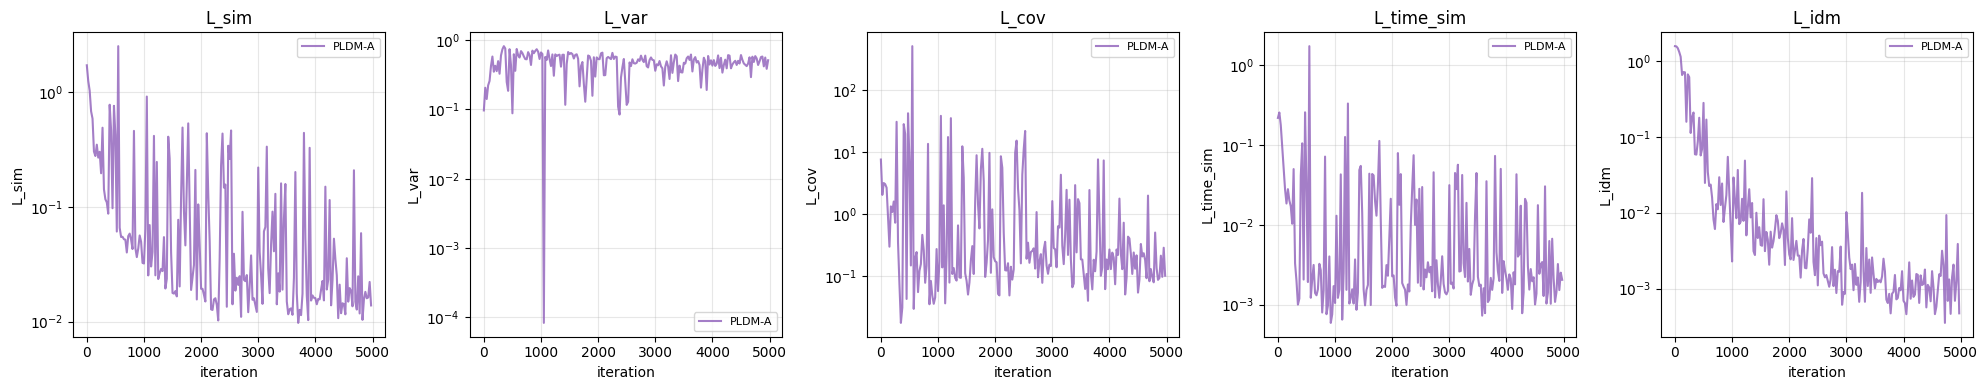

In [9]:
if 'PLDM-A (5-term)' in loaded:
    pldm_keys = ['L_sim', 'L_var', 'L_cov', 'L_time_sim', 'L_idm']
    fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True)
    cfg_p, df_p = loaded['PLDM-A (5-term)']
    for ax, key in zip(axes, pldm_keys):
        sub = df_p[key].dropna() if key in df_p.columns else pd.Series(dtype=float)
        if len(sub):
            ax.plot(sub.index, sub.values, label='PLDM-A', alpha=0.85, color='C4')
        ax.set_xlabel('iteration'); ax.set_ylabel(key)
        ax.set_yscale('symlog', linthresh=1e-4)
        ax.set_title(key)
        ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('skip: no PLDM run loaded')


### Section 7.2: Latent-health diagnostics including PLDM-A

PR(z) and probe R^2 trajectories with PLDM-A overlaid on the 4 JEPA variants.


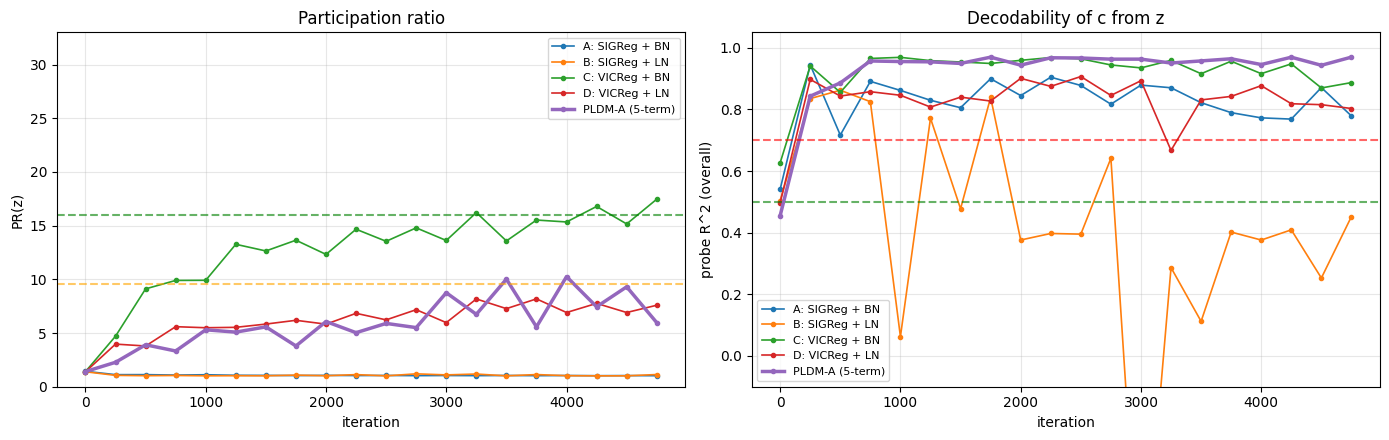

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax_pr, ax_r2 = axes
for label, (cfg, df) in loaded.items():
    sub_pr = df['diag/pr'].dropna() if 'diag/pr' in df.columns else pd.Series(dtype=float)
    sub_r2 = df['diag/r2_overall'].dropna() if 'diag/r2_overall' in df.columns else pd.Series(dtype=float)
    lw = 2.5 if 'PLDM' in label else 1.2
    if len(sub_pr): ax_pr.plot(sub_pr.index, sub_pr.values, label=label, marker='o', markersize=3, linewidth=lw)
    if len(sub_r2): ax_r2.plot(sub_r2.index, sub_r2.values, label=label, marker='o', markersize=3, linewidth=lw)
ax_pr.axhline(PR_HEALTHY, color='g', linestyle='--', alpha=0.6)
ax_pr.axhline(PR_FALLBACK, color='orange', linestyle='--', alpha=0.6)
ax_pr.set_xlabel('iteration'); ax_pr.set_ylabel('PR(z)'); ax_pr.set_title('Participation ratio')
ax_pr.set_ylim(0, D + 1); ax_pr.grid(True, alpha=0.3); ax_pr.legend(fontsize=8)
ax_r2.axhline(R2_PASS_LO, color='g', linestyle='--', alpha=0.6)
ax_r2.axhline(R2_PASS_HI, color='r', linestyle='--', alpha=0.6)
ax_r2.set_xlabel('iteration'); ax_r2.set_ylabel('probe R^2 (overall)'); ax_r2.set_title('Decodability of c from z')
ax_r2.set_ylim(-0.1, 1.05); ax_r2.grid(True, alpha=0.3); ax_r2.legend(fontsize=8)
plt.tight_layout(); plt.show()


### Section 7.3: Updated 5-variant 2x2 quadrant table


In [11]:
summary_rows_v2 = []
for label, (cfg, df) in loaded.items():
    pr = final_values(df, 'diag/pr')
    r2 = final_values(df, 'diag/r2_overall')
    L_sim_v = final_values(df, 'L_sim')
    L_pred_v = final_values(df, 'loss_pred')
    L_anti_v = final_values(df, 'loss_anticollapse')
    summary_rows_v2.append({
        'variant': label,
        'PR@5k': pr,
        'r2@5k': r2,
        'L_pred_or_sim@5k': L_pred_v if L_pred_v is not None else L_sim_v,
        'L_anti_total@5k': L_anti_v,
        'quadrant': quadrant(pr, r2),
    })
summary_df_v2 = pd.DataFrame(summary_rows_v2)
print(summary_df_v2.to_string(index=False, float_format=lambda x: f'{x:.3f}' if x is not None else 'n/a'))


        variant  PR@5k  r2@5k  L_pred_or_sim@5k  L_anti_total@5k     quadrant
 A: SIGReg + BN  1.025  0.779             0.000            0.081      TRIVIAL
 B: SIGReg + LN  1.135  0.452             0.003            0.124         DEAD
 C: VICReg + BN 17.463  0.887             0.002            0.083 TRIVIAL_LITE
 D: VICReg + LN  7.588  0.803             0.012            4.007      TRIVIAL
PLDM-A (5-term)  5.966  0.970             0.014              NaN      TRIVIAL


### Section 7.4: Decision string update (REGIME_CONFIRMED / DATA_SCALE_BOUND / PLDM_PARTIAL)

Per `SESSION5_PLDM_BASELINE.md` Section 7.4 the PLDM outcome is one of
three categories, evaluated on PLDM-A only:

- REGIME_CONFIRMED: PR_PLDM > 16 AND 0.5 < r2_PLDM < 0.7.
  LeWM Two-Room precedent confirmed on physics data.
- DATA_SCALE_BOUND: PR_PLDM <= 16 (any r2).
  Failure is not regulariser-specific; data-scale-bound. -> Session 5.5.
- PLDM_PARTIAL: PR > 16 but r2 outside (0.5, 0.7).


In [12]:
def pldm_decision(summary: pd.DataFrame) -> str:
    rows = summary[summary['variant'].str.contains('PLDM', case=False, na=False)]
    if rows.empty:
        return 'NO_PLDM_DATA'
    r = rows.iloc[0]
    pr = r['PR@5k']; r2 = r['r2@5k']
    if pr is None or r2 is None:
        return 'PLDM-A logged no final diagnostics'
    if pr <= PR_HEALTHY:
        return (f'DATA_SCALE_BOUND: PLDM-A PR={pr:.2f} (<= {PR_HEALTHY:.0f}); '
                f'both regularisers collapse on 5 cases. r2={r2:.3f}. '
                f'-> Session 5.5 (expand to 10-12 cases) on BOTH SIGReg and PLDM.')
    if R2_PASS_LO < r2 < R2_PASS_HI:
        return (f'REGIME_CONFIRMED: PLDM-A PR={pr:.2f}, r2={r2:.3f} in healthy band. '
                f'LeWM Two-Room precedent confirmed; Session 6 with PLDM as primary.')
    return (f'PLDM_PARTIAL: PLDM-A PR={pr:.2f} cleared the threshold but r2={r2:.3f} '
            f'outside (0.5, 0.7). Outcome-dependent next session.')

print('=== Session 5.PLDM outcome ===')
print(pldm_decision(summary_df_v2))


=== Session 5.PLDM outcome ===
DATA_SCALE_BOUND: PLDM-A PR=5.97 (<= 16); both regularisers collapse on 5 cases. r2=0.970. -> Session 5.5 (expand to 10-12 cases) on BOTH SIGReg and PLDM.
